#### Task 1
- <small>f20_200iso_18mm_125sp</small>
  - <small>Aperture (f/20): A very narrow aperture allows less light but increases the depth of field, keeping both foreground and background in focus.</small>
  - <small>ISO (200): A relatively low ISO value was chosen to reduce noise and preserve image clarity.</small>
  - <small>Focal Length (18mm): A wide-angle setting was used to capture a broader scene with more context.</small>
  - <small>Shutter Speed (1/125s): A moderate shutter speed balances light capture while avoiding motion blur</small>
  - <small>This configuration is suitable for bright environments where capturing fine detail across the entire frame is important.</small>
- <small>f20_200iso_35mm_125sp</small>
  - <small>Focal Length (35mm):Compared to 18mm, this provides a narrower field of view, emphasizing the subject while still preserving background detail.</small>
  - <small>This setting highlights how focal length influences composition while keeping exposure similar to the wide-angle case.</small>
- <small>f22_1600iso_35mm_800sp</small>
  - <small>Aperture (f/22): An even narrower aperture maximizes depth of field, but allows very little light.</small>
  - <small>ISO (1600): A high ISO compensates for the small aperture and fast shutter speed, making the sensor more sensitive to light, though it introduces some noise.</small>
  - <small>Shutter Speed (1/800s): A very fast shutter speed reduces motion blur, ideal for capturing moving objects or shooting in bright conditions.</small>
  - <small>This configuration demonstrates the trade-off between depth of field, exposure time, and noise.</small>
- <small>f3.2_100iso_35mm_2500sp</small>
  - <small>Aperture (f/3.2): A wide aperture lets in much more light, producing a shallow depth of field with strong subject-background separation.</small>
  - <small>ISO (100): The lowest ISO minimizes noise, ideal for brightly lit conditions.</small>
  - <small>Shutter Speed (1/2500s): A very fast shutter speed prevents overexposure despite the wide aperture and bright environment.</small>
  - <small>This configuration is excellent for isolating a subject with blurred background (bokeh effect) while keeping the image noise-free.</small>

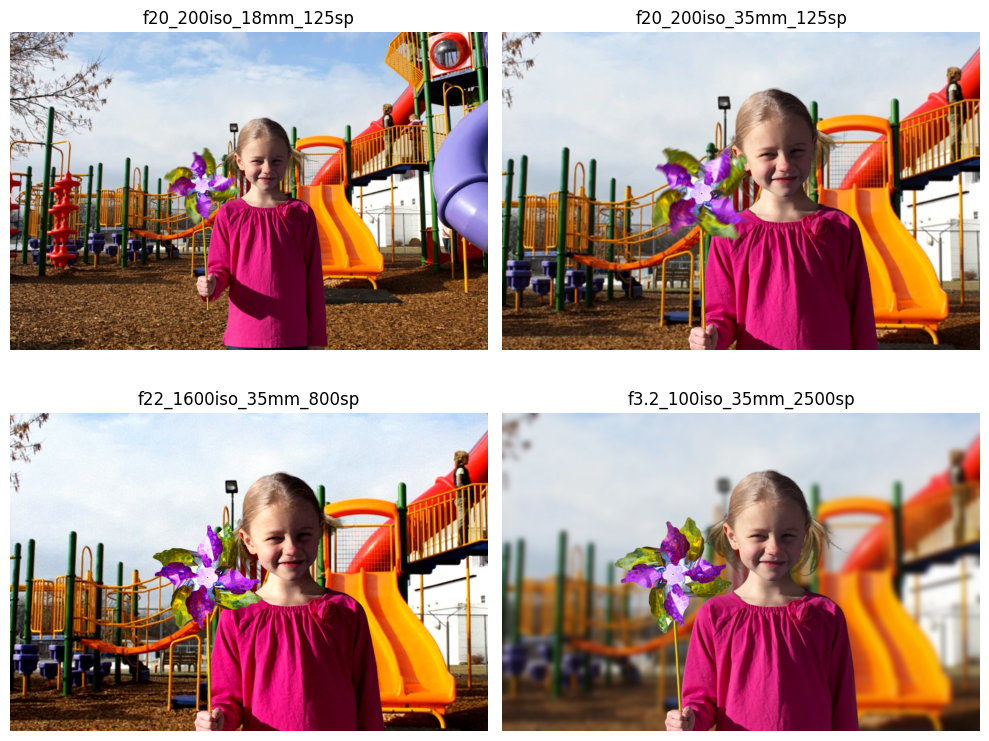

In [1]:
import cv2
import matplotlib.pyplot as plt

img1 = cv2.imread("../src/data/f20_200iso_18mm_125sp.png")
img2 = cv2.imread("../src/data/f20_200iso_35mm_125sp.png")
img3 = cv2.imread("../src/data/f22_1600iso_35mm_800sp.png")
img4 = cv2.imread("../src/data/f3.2_100iso_35mm_2500sp.png")

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
img3 = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)
img4 = cv2.cvtColor(img4, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.imshow(img1)
plt.title("f20_200iso_18mm_125sp")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(img2)
plt.title("f20_200iso_35mm_125sp")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(img3)
plt.title("f22_1600iso_35mm_800sp")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(img4)
plt.title("f3.2_100iso_35mm_2500sp")
plt.axis("off")

plt.tight_layout()
plt.show()

#### Task 2.1

In [2]:
import cv2
import numpy as np

def grey_world(img):
    result = img.copy().astype(np.float32)
    avg_b, avg_g, avg_r = cv2.mean(img)[:3]
    avg_gray = (avg_b + avg_g + avg_r) / 3
    result[...,0] *= avg_gray / avg_b
    result[...,1] *= avg_gray / avg_g
    result[...,2] *= avg_gray / avg_r
    return np.clip(result, 0, 255).astype(np.uint8)

def white_patch(img):
    result = img.copy().astype(np.float32)
    max_b, max_g, max_r = np.max(img[:,:,0]), np.max(img[:,:,1]), np.max(img[:,:,2])
    result[:,:,0] *= 255.0 / max_b
    result[:,:,1] *= 255.0 / max_g
    result[:,:,2] *= 255.0 / max_r
    return np.clip(result, 0, 255).astype(np.uint8)

In [3]:
def unsharp_mask(img, k=1.5):
    blurred = cv2.GaussianBlur(img, (5,5), 0)
    sharpened = cv2.addWeighted(img, 1+k, blurred, -k, 0)
    return sharpened

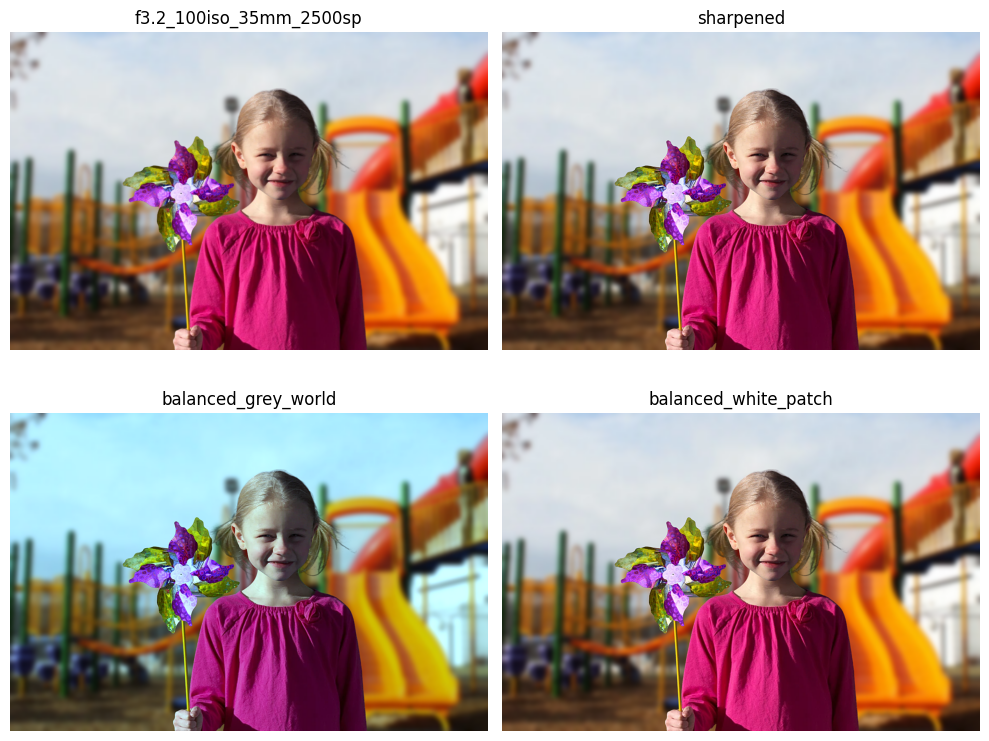

In [4]:
img = cv2.imread("../src/data/f3.2_100iso_35mm_2500sp.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

sharpened = unsharp_mask(img)
balanced_gw = grey_world(sharpened)
balanced_wp = white_patch(sharpened)

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.imshow(img)
plt.title("f3.2_100iso_35mm_2500sp")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(sharpened)
plt.title("sharpened")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(balanced_gw)
plt.title("balanced_grey_world")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(balanced_wp)
plt.title("balanced_white_patch")
plt.axis("off")

plt.tight_layout()
plt.show()

#### Task 2.2

Histogram Equalization

&emsp;&emsp;Enhances overall contrast, especially detail in shadows and highlights.

&emsp;&emsp;Disadvantages: May cause color distortion or amplify noise.

Contrast Stretch

&emsp;&emsp;User-controllable (alpha enhances contrast, beta adjusts brightness).

&emsp;&emsp;Suitable for targeted enhancement, maintaining more natural colors.

In [5]:
def hist_equalization(img):
    img_yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)
    img_yuv[:,:,0] = cv2.equalizeHist(img_yuv[:,:,0])
    return cv2.cvtColor(img_yuv, cv2.COLOR_YUV2BGR)

def contrast_stretching(img, alpha=1.5, beta=20):
    # alpha: 对比度系数, beta: 亮度偏移
    new_img = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)
    return new_img

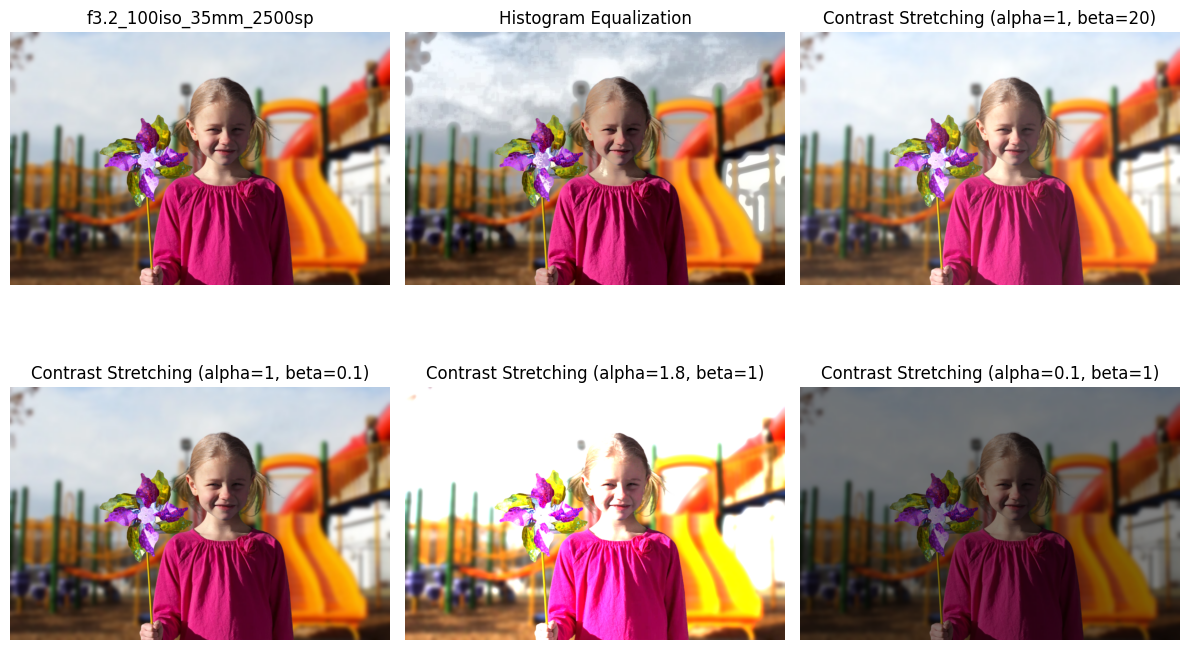

In [6]:
img = cv2.imread("../src/data/f3.2_100iso_35mm_2500sp.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_eq = hist_equalization(img)
img_cs0 = contrast_stretching(img, alpha=1, beta=20)
img_cs1 = contrast_stretching(img, alpha=1, beta=0.1)
img_cs2 = contrast_stretching(img, alpha=1.8, beta=1)
img_cs3 = contrast_stretching(img, alpha=0.5, beta=1)

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(img)
plt.title("f3.2_100iso_35mm_2500sp")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(img_eq)
plt.title("Histogram Equalization")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(img_cs0)
plt.title("Contrast Stretching (alpha=1, beta=20)")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(img_cs1)
plt.title("Contrast Stretching (alpha=1, beta=0.1)")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(img_cs2)
plt.title("Contrast Stretching (alpha=1.8, beta=1)")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(img_cs3)
plt.title("Contrast Stretching (alpha=0.1, beta=1)")
plt.axis("off")

plt.tight_layout()
plt.show()